# TPM034A Machine Learning for socio-technical systems
## `Mini-project #2: Identifying ‘the silent middle’ in citizen participation consultation in the Netherlands`

**Delft University of Technology**<br>
**Q2 2025**<br>
**Module manager:** Dr. Sander van Cranenburgh <br>
**Instructors:** Dr. Sander van Cranenburgh, Dr. Giacomo Marangoni, Dr. Amir Pooyan Afghari <br>
**TAs:**  Francisco Garrido Valenzuela <br>

## `Learning objectives:`
This mini-project addresses LO3, LO4, LO5 and LO6 in the course.

After the course, students can:
1.	explain fundamental concepts of machine learning (ML).
2.	conceptually explain the workings of a selected number of ML models and eXplainable AI (XAI) techniques, and apply these to empirical data.
3.	**identify applications of ML and XAI techniques in real-world socio-technical systems.**
4.	**examine the impact of ML-based solutions and interventions on individuals, organisations, and society through XAI.**
5.	**conduct an in-depth analysis of a real-world socio-technical challenge, by applying ML and XAI to empirical data.**
6.	**reflect on the strengths and limitations of ML and XAI in real-world socio-technical systems.**

## `Project description` <br>

### **Introduction**

Populytics, a recently found company, studies the preferences of Dutch citizens about public policy dilemmas (such as wind turbines, refugee centers, and health care budgeting) in the Netherlands by carrying out large-scale online consultations using the scientific PVE-method. By gaining insight into the worries and preferences of citizens, the company provides the government (and other decision makers) with helpful insights to make better decisions. Within these consultations, there is often a large group of respondents with moderate preferences. This is a group that often says they haven’t actively voiced their opinion on the topic. Therefore, we colloquially refer to this group as ‘the silent middle’.
There could be many reasons behind this moderate preference profile. Are they disinterested in the topic? Or unknowledgeable? Or is it a well-considered, nuanced position? And in the latter case, why? Are they reluctant to change, or realistic about social change? Or is something else entirely at play?

*The objective of this mini-project is to predict this silent middle and the underlying reasons behind their ‘silence’. Are there recognizable, coherent and recurrent subgroups? What questions or (demographic) factors allow you to identify these subgroups?*<br>

### **Data**
You have access to the following data for a sample of citizens in the Netherlands:
1.	The demographic information and individual characteristics of the citizens
2.	The characteristics of the projects
3.	The preferences of citizens for each project
4.	The motivation behind citizens’ preferences for each project

The file 'data description.pdf' provides a brief explanation of the data.

### **Tasks and grading**

There are 6 tasks in this project. In total, **10 points** can be earned for these 5 tasks.The weight per task is shown below.
1. Prepare the data and apply a proper analytical model to predict “the silent middle” group among citizens  **[3.5 points]**
2. Identify the most important features contributing to the “silent middle” group  **[1 point]**
3. How does the “motivation” of the respondants contribute to the prediction of the “silent middle” group? **[0.5 points]**
4. Name two analytical strengths and two analytical limitations of your selected model and data to predict “the silent middle” group **[2 points]**
5. Discuss the societal impact of these strengths and limitations on individuals, organisations, and society  **[2 points]**
6. Propose a potential analytical solution (related to model or data) for mitigating the most severe limitation  **[1 point]**

### **Grading criteria:**

For the first 2 tasks:
**Correctness of methods and techniques (45%)**
**Completeness (45%)**
**Coding skills (10%)**

For tasks 3, 4 and 5:
**Depth of critical thinking and creativity (60%)**
**Completeness (40%)**

### **Submission**
When you finish the project, please submit the Jupyter Notebook file of your work to Brightspace and prepare a final presentation (including the results of the tasks) to be delivered on the presentations day.

This project is a group project and so each group must submit one Jupyter Notebook file. However, it is expected that all members of the group contribute to the project. **Please prepare a short statement about the "Members contributions" in your final presentation and outline who did what in the project.**

The deadline for submission is **09/01/2026**.

In [15]:
import pandas as pd

In [16]:
raw_df = pd.read_excel('Data files/fulldataset.xlsx')

In [17]:
raw_df.head()

,id,time,panel,study,level,sector,lossesgains,ct1type,ct1_1,motct1_1,...,giveadviceother,advice,choicesteering,honestresearch,subjectimportant,hardunderstanding,usemoreoften,choiceslearning,decisionaccepting,decisiontrusting
0,99d291ee-d6e7-4a4e-a33e-769e18b09376,00:09:52,0,alblasserwaard,regional,energy & environment,losses > gains,points,40.0,"""""",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,f0bf1ee0-4762-42a4-a198-d5ff278cbf56,00:44:45,0,alblasserwaard,regional,energy & environment,losses > gains,points,40.0,"""minstens 2 km van bewoond gebied""",...,NaN,residents more important then experts,NaN,Neutral,Strongly agree,Neutral,Agree,Agree,Agree,Agree
2,22aaecd8-d765-494e-9248-8cb54f64ad3d,00:14:00,0,alblasserwaard,regional,energy & environment,losses > gains,points,40.0,"""We wonen in het mooiste stukje Nederland. Dit...",...,NaN,only residents,NaN,Strongly disagree,Agree,Strongly disagree,Strongly agree,Neutral,Strongly disagree,Neutral
3,ee78402d-eaa7-43d2-b5b5-30f68b384d00,00:25:25,0,alblasserwaard,regional,energy & environment,losses > gains,points,15.0,"""Zie de hierbovengenoemde argumenten""",...,NaN,residents more important then experts,NaN,Neutral,Strongly disagree,Disagree,Agree,Disagree,Neutral,Neutral
4,2b411024-8d1f-460d-9bcf-e378779faa6b,00:44:44,0,alblasserwaard,regional,energy & environment,losses > gains,points,20.0,"""Geplande windmolens van 240 meter hoog passen...",...,NaN,equally important,NaN,Neutral,Strongly agree,Strongly disagree,Agree,Neutral,Strongly agree,Strongly agree


In [18]:
pd.set_option('display.max_info_columns', raw_df.shape[1])
raw_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56329 entries, 0 to 56328
Data columns (total 91 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       56329 non-null  object 
 1   time                     52293 non-null  object 
 2   panel                    56329 non-null  int64  
 3   study                    56329 non-null  object 
 4   level                    56329 non-null  object 
 5   sector                   56329 non-null  object 
 6   lossesgains              56329 non-null  object 
 7   ct1type                  56329 non-null  object 
 8   ct1_1                    56329 non-null  float64
 9   motct1_1                 35422 non-null  object 
 10  ct1_2                    56329 non-null  float64
 11  motct1_2                 36439 non-null  object 
 12  ct1_3                    56329 non-null  float64
 13  motct1_3                 34976 non-null  object 
 14  ct1_4                 

In [69]:
import re
import numpy as np
import pandas as pd

df = raw_df.copy()

# --- Identify choice columns ---
ct1_cols = [c for c in df.columns if c.startswith("ct1_")]
ct2_cols = [c for c in df.columns if c.startswith("ct2_")]
ct_cols  = ct1_cols + ct2_cols

mct_cols = [c for c in df.columns if c.startswith("motct")]

print("ct1:", len(ct1_cols), "ct2:", len(ct2_cols), "total ct:", len(ct_cols), "total mct:", len(mct_cols))


ct1: 19 ct2: 11 total ct: 30 total mct: 30


In [70]:
# Ensure ct columns are numeric (some may be stored as object)
for c in ct_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Per study, compute option medians, then respondent mean absolute deviation from those medians
study_col = "study"  # based on your info() screenshot

groups = df[study_col]   # or raw_df["study"] if you're using raw_df directly

def add_deviation_scores(group: pd.DataFrame) -> pd.DataFrame:
    med = group[ct_cols].median(numeric_only=True)
    # Mean absolute deviation across available options for each respondent
    mad = (group[ct_cols].sub(med, axis=1)).abs().mean(axis=1, skipna=True)
    group = group.copy()
    group["ct_mad_from_median"] = mad
    return group

df = df.groupby(study_col, group_keys=False).apply(add_deviation_scores)

# Define “silent middle” as the lowest-deviation ~50% within each study (matches the “often ~50%” description)
df["silent_middle"] = df.groupby(study_col)["ct_mad_from_median"].transform(lambda s: s <= s.median()).astype(int)

df[["ct_mad_from_median", "silent_middle"]].describe()


C:\Users\juliu\AppData\Local\Temp\ipykernel_9364\3347743768.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(study_col, group_keys=False).apply(add_deviation_scores)


,ct_mad_from_median,silent_middle
count,56329.000000,56329.000000
mean,3.208024,0.534520
std,3.426821,0.498811
min,0.000000,0.000000
25%,0.477273,0.000000
50%,1.812500,1.000000
75%,5.000000,1.000000
max,18.062500,1.000000


In [ ]:


df["motivationamount"] = df[mct_cols].notna().sum(axis=1)

df["motivation_length"] = (
    df[mct_cols]
    .fillna("")
    .astype(str)
    .apply(lambda row: sum(len(s) for s in row), axis=1)
)

# neg_words = ["niet", "geen", "nooit"]

# df["uses_negation"] = (
#     df[mct_cols]
#     .fillna("")
#     .astype(str)
#     .apply(
#         lambda row: any(
#             any(f" {w} " in f" {s.lower()} " for w in neg_words)
#             for s in row
#         ),
#         axis=1
#     )
#     .astype(int)
# )
# 3) Log-length (often better behaved)
df["logmotivationlength"] = np.log1p(df["motivation_length"])

In [72]:
# --- Explicitly define columns to exclude ---

# Choice-task outcome columns (already defined earlier)
leakage_cols = set(ct_cols + ["ct_mad_from_median", "silent_middle"])

# Raw motivation text columns
motivation_text_cols = {c for c in df.columns if c.startswith("motct")}

# Study / task-structure columns
study_structure_cols = {"study", "ct1type", "ct2type"}

# Identifiers
id_like = {"id", "time"}

# Combine all exclusions
exclude = leakage_cols | motivation_text_cols | study_structure_cols | id_like | {"motivation_length"}

# Build X and y
X = df[[c for c in df.columns if c not in exclude]].copy()
y = df["silent_middle"].copy()

print("X shape:", X.shape)
print("Excluded columns:", sorted(exclude))


X shape: (56329, 28)
Excluded columns: ['ct1_1', 'ct1_10', 'ct1_11', 'ct1_12', 'ct1_13', 'ct1_14', 'ct1_15', 'ct1_16', 'ct1_17', 'ct1_18', 'ct1_19', 'ct1_2', 'ct1_3', 'ct1_4', 'ct1_5', 'ct1_6', 'ct1_7', 'ct1_8', 'ct1_9', 'ct1type', 'ct2_1', 'ct2_10', 'ct2_11', 'ct2_2', 'ct2_3', 'ct2_4', 'ct2_5', 'ct2_6', 'ct2_7', 'ct2_8', 'ct2_9', 'ct2type', 'ct_mad_from_median', 'id', 'motct1_1', 'motct1_10', 'motct1_11', 'motct1_12', 'motct1_13', 'motct1_14', 'motct1_15', 'motct1_16', 'motct1_17', 'motct1_18', 'motct1_19', 'motct1_2', 'motct1_3', 'motct1_4', 'motct1_5', 'motct1_6', 'motct1_7', 'motct1_8', 'motct1_9', 'motct2_1', 'motct2_10', 'motct2_11', 'motct2_2', 'motct2_3', 'motct2_4', 'motct2_5', 'motct2_6', 'motct2_7', 'motct2_8', 'motct2_9', 'motivation_length', 'silent_middle', 'study', 'time']


In [73]:
display(X.head())

,panel,level,sector,lossesgains,grade,age,education,gender,finance,dailylife,...,choicesteering,honestresearch,subjectimportant,hardunderstanding,usemoreoften,choiceslearning,decisionaccepting,decisiontrusting,motivationamount,log_motivation_length
0,0,regional,energy & environment,losses > gains,NaN,35-64,high,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8,2.833213
1,0,regional,energy & environment,losses > gains,7.0,65+,middle,NaN,NaN,NaN,...,NaN,Neutral,Strongly agree,Neutral,Agree,Agree,Agree,Agree,8,4.110874
2,0,regional,energy & environment,losses > gains,7.0,35-64,high,NaN,NaN,NaN,...,NaN,Strongly disagree,Agree,Strongly disagree,Strongly agree,Neutral,Strongly disagree,Neutral,8,5.823046
3,0,regional,energy & environment,losses > gains,NaN,35-64,high,NaN,NaN,NaN,...,NaN,Neutral,Strongly disagree,Disagree,Agree,Disagree,Neutral,Neutral,8,6.448889
4,0,regional,energy & environment,losses > gains,8.0,35-64,high,NaN,NaN,NaN,...,NaN,Neutral,Strongly agree,Strongly disagree,Agree,Neutral,Strongly agree,Strongly agree,8,7.537963


In [74]:
for x in X.columns:
    print(x)

panel
level
sector
lossesgains
grade
age
education
gender
finance
dailylife
health
home
nevergiaveadvice
giveadvicesurvey
giveadvicemeeting
giveadviceinterestgroup
giveadviceother
advice
choicesteering
honestresearch
subjectimportant
hardunderstanding
usemoreoften
choiceslearning
decisionaccepting
decisiontrusting
motivationamount
log_motivation_length


In [75]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

def rmse_from_proba(y_true, y_proba):
    y_proba = np.asarray(y_proba)
    p = y_proba[:, 1] if y_proba.ndim == 2 else y_proba
    return np.sqrt(mean_squared_error(y_true, p))

def r2_from_proba(y_true, y_proba):
    y_proba = np.asarray(y_proba)
    p = y_proba[:, 1] if y_proba.ndim == 2 else y_proba
    return r2_score(y_true, p)

In [76]:
bad_cols = X.select_dtypes(exclude=["number"]).columns.tolist()
print("Non-numeric columns in X:", bad_cols)

Non-numeric columns in X: ['level', 'sector', 'lossesgains', 'age', 'education', 'gender', 'finance', 'dailylife', 'health', 'home', 'nevergiaveadvice', 'giveadvicesurvey', 'giveadvicemeeting', 'giveadviceinterestgroup', 'giveadviceother', 'advice', 'choicesteering', 'honestresearch', 'subjectimportant', 'hardunderstanding', 'usemoreoften', 'choiceslearning', 'decisionaccepting', 'decisiontrusting']


In [82]:
from pathlib import Path
import pickle

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import make_scorer, f1_score, balanced_accuracy_score, r2_score
from sklearn.metrics import mean_squared_error

# 1) Preprocessing
cat_cols = [c for c in X.columns if X[c].dtype == "object" or str(X[c].dtype).startswith("string")]
num_cols = [c for c in X.columns if c not in cat_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median"))
        ]), num_cols),

        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("oh", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols),
    ]
)

all_missing_cols = X.columns[X.isna().all()].tolist()
print("Columns that are entirely NaN in full X:", all_missing_cols)

# 2) RF model — IMPORTANT: n_jobs=1 to avoid nested parallelism slowdown
rf = RandomForestClassifier(
    random_state=5,
    n_jobs=1,                 # <-- key change for speed predictability
    class_weight="balanced"
)

rf_pipe = Pipeline(steps=[("prep", preprocess), ("rf", rf)])

# 3) Hyperparameter distributions (good coverage, small search)
hyperparameter_space = {
    "rf__n_estimators": [300],                 # fixed
    "rf__max_depth": [None, 10, 16, 24],
    "rf__min_samples_leaf": [1, 5, 10, 20],
    "rf__max_features": ["sqrt", 0.5, 0.8],
    "rf__min_samples_split": [2, 10, 30],
    "rf__bootstrap": [True],
}

cv = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=42)

for i, (tr, te) in enumerate(cv.split(X, y, groups=groups)):
    all_missing_in_train = X.iloc[tr].columns[X.iloc[tr].isna().all()].tolist()
    if all_missing_in_train:
        print(f"Fold {i} all-missing in TRAIN:", all_missing_in_train)

scoring = {
    "auc": "roc_auc",
    "f1": make_scorer(f1_score),
    "bal_acc": make_scorer(balanced_accuracy_score),

    # NOTE: response_method instead of needs_proba
    "rmse": make_scorer(
        rmse_from_proba,
        greater_is_better=False,
        response_method="predict_proba",
    ),
    "r2": make_scorer(
        r2_from_proba,
        response_method="predict_proba",
    ),
}

# 4) Budget: ~2 candidates (2 * 5 folds ≈ ~5.2 minutes based on your timing)
rf_search = RandomizedSearchCV(
    rf_pipe,
    param_distributions=hyperparameter_space,
    n_iter=2,                  # <= likely to finish under ~7 minutes
    scoring=scoring,
    refit="auc",
    error_score="raise",
    cv=cv,
    n_jobs=-1,                 # parallelise across folds/candidates
    random_state=42,
    verbose=2,
    return_train_score=True
)

pickle_path = Path("RF_randomsearch_budget912min.pickle")

if not pickle_path.exists():
    rf_search.fit(X, y, groups=groups)
    with open(pickle_path, "wb") as f:
        pickle.dump(rf_search, f)
else:
    with open(pickle_path, "rb") as f:
        rf_search = pickle.load(f)
best_idx = rf_search.best_index_
cvres = rf_search.cv_results_


print([k for k in cvres.keys() if "rmse" in k or "r2" in k])


Columns that are entirely NaN in full X: []
Fitting 3 folds for each of 2 candidates, totalling 6 fits
['split0_test_rmse', 'split1_test_rmse', 'split2_test_rmse', 'mean_test_rmse', 'std_test_rmse', 'rank_test_rmse', 'split0_train_rmse', 'split1_train_rmse', 'split2_train_rmse', 'mean_train_rmse', 'std_train_rmse', 'split0_test_r2', 'split1_test_r2', 'split2_test_r2', 'mean_test_r2', 'std_test_r2', 'rank_test_r2', 'split0_train_r2', 'split1_train_r2', 'split2_train_r2', 'mean_train_r2', 'std_train_r2']


In [83]:


print("Best parameters:", rf_search.best_params_)
print(f"AUC (CV):               {rf_search.best_score_:.4f}")
print(f"F1 (CV):                {cvres['mean_test_f1'][best_idx]:.4f}")
print(f"Balanced accuracy (CV): {cvres['mean_test_bal_acc'][best_idx]:.4f}")

print("\nCalibration-style metrics (probability-based)")
print("AUC Train:", cvres["mean_train_auc"][best_idx])
print("AUC Test :", cvres["mean_test_auc"][best_idx])



Best parameters: {'rf__n_estimators': 300, 'rf__min_samples_split': 2, 'rf__min_samples_leaf': 20, 'rf__max_features': 'sqrt', 'rf__max_depth': 24, 'rf__bootstrap': True}
AUC (CV):               0.5654
F1 (CV):                0.5309
Balanced accuracy (CV): 0.5331

Calibration-style metrics (probability-based)
AUC Train: 0.75166134009039
AUC Test : 0.565428049336025


In [84]:
rmse_train = -cvres["mean_train_rmse"][best_idx]
rmse_test  = -cvres["mean_test_rmse"][best_idx]

r2_train = cvres["mean_train_r2"][best_idx]
r2_test  = cvres["mean_test_r2"][best_idx]

print(f"RMSE   Train | Test: {rmse_train:.4f} | {rmse_test:.4f}")
print(f"R²     Train | Test: {r2_train:.4f} | {r2_test:.4f}")

RMSE   Train | Test: 0.4625 | 0.4965
R²     Train | Test: 0.1401 | 0.0094


In [85]:
best_idx = rf_search.best_index_
cvres = rf_search.cv_results_

rmse_splits = [cvres[f"split{i}_test_rmse"][best_idx] for i in range(3)]
r2_splits   = [cvres[f"split{i}_test_r2"][best_idx]   for i in range(3)]

print("RMSE per fold:", rmse_splits)
print("R2 per fold:", r2_splits)

RMSE per fold: [np.float64(-0.49728944456114077), np.float64(-0.4967823352593572), np.float64(-0.49537709195281426)]
R2 per fold: [np.float64(0.00364673236045554), np.float64(0.009199682085198169), np.float64(0.015254986674627435)]


In [86]:
import numpy as np
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import mean_squared_error, r2_score
best_model = rf_search.best_estimator_
probs = cross_val_predict(
    best_model,
    X,
    y,
    cv=cv,
    groups=groups,
    method="predict_proba",
    n_jobs=-1
)[:, 1]   # probability of class 1 (silent middle)
rmse = np.sqrt(mean_squared_error(y, probs))
r2 = r2_score(y, probs)

print("CV RMSE (probabilities):", round(rmse, 4))
print("CV R²   (probabilities):", round(r2, 4))

CV RMSE (probabilities): 0.4964
CV R²   (probabilities): 0.0096


In [87]:
import numpy as np

for i, (train_idx, test_idx) in enumerate(cv.split(X, y, groups)):
    ytr = y.iloc[train_idx]
    yte = y.iloc[test_idx]
    print(i, "train classes:", np.bincount(ytr), "test classes:", np.bincount(yte))

0 train classes: [15434 17324] test classes: [10786 12785]
1 train classes: [21835 25159] test classes: [4385 4950]
2 train classes: [15171 17735] test classes: [11049 12374]


In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Best fitted pipeline
best_model = rf_search.best_estimator_

rf_best = best_model.named_steps["rf"]
prep = best_model.named_steps["prep"]

# Get feature names after preprocessing
cat_cols = prep.transformers_[1][2]  # original categorical columns
num_cols = prep.transformers_[0][2]  # original numeric columns

oh = prep.named_transformers_["cat"].named_steps["oh"]
cat_feature_names = oh.get_feature_names_out(cat_cols)

feature_names = np.concatenate([np.array(num_cols), cat_feature_names])

# Feature importances
importances = rf_best.feature_importances_
fi = pd.Series(importances, index=feature_names).sort_values(ascending=False)


In [89]:
from sklearn.utils import shuffle

y_perm = shuffle(y, random_state=42)

probs_perm = cross_val_predict(
    best_model,
    X,
    y_perm,
    cv=cv,
    groups=groups,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

r2_perm = r2_score(y_perm, probs_perm)
print("Permuted R²:", r2_perm)

Permuted R²: -0.0063401617190397275


In [90]:
r2_folds = [
    cvres[f"split{i}_test_r2"][best_idx]
    for i in range(3)
]

print("Fold-wise R²:", r2_folds)
print("Mean R²:", np.mean(r2_folds))

Fold-wise R²: [np.float64(0.00364673236045554), np.float64(0.009199682085198169), np.float64(0.015254986674627435)]
Mean R²: 0.00936713370676038


In [91]:
p_null = np.full_like(y, y.mean(), dtype=float)

rmse_null = np.sqrt(mean_squared_error(y, p_null))
r2_null = r2_score(y, p_null)

print("Null RMSE:", rmse_null)
print("Null R²:", r2_null)

Null RMSE: 0.4988069180632818
Null R²: 0.0


In [92]:
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedGroupKFold, cross_val_predict
from sklearn.metrics import r2_score, mean_squared_error

# --- 1) Columns ---
cat_cols = [c for c in X.columns if X[c].dtype == "object" or str(X[c].dtype).startswith("string")]
num_cols = [c for c in X.columns if c not in cat_cols]

# --- 2) Preprocess: impute + scale numeric, impute + one-hot categorical ---
preprocess_mlp = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),          # MLP needs this
        ]), num_cols),
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("oh", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]), cat_cols),
    ],
    remainder="drop"
)

# --- 3) Small MLP model ---
mlp = MLPClassifier(
    hidden_layer_sizes=(32,),   # small network
    activation="relu",
    alpha=1e-4,                 # L2 regularisation
    learning_rate_init=1e-3,
    max_iter=200,               # early stopping will usually stop earlier
    early_stopping=True,
    n_iter_no_change=10,
    random_state=42
)

mlp_pipe = Pipeline(steps=[
    ("prep", preprocess_mlp),
    ("mlp", mlp)
])

# --- 4) Group-aware CV (same idea as your RF) ---
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

# --- 5) Out-of-fold probabilities + R² ---
probs = cross_val_predict(
    mlp_pipe,
    X, y,
    cv=cv,
    groups=groups,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

rmse = np.sqrt(mean_squared_error(y, probs))
r2 = r2_score(y, probs)

print("MLP CV RMSE (probabilities):", round(rmse, 4))
print("MLP CV R²   (probabilities):", round(r2, 4))


MLP CV RMSE (probabilities): 0.4976
MLP CV R²   (probabilities): 0.005


In [93]:
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedGroupKFold, cross_val_predict
from sklearn.metrics import mean_squared_error, r2_score

# 1) Columns
cat_cols = [c for c in X.columns if X[c].dtype == "object" or str(X[c].dtype).startswith("string")]
num_cols = [c for c in X.columns if c not in cat_cols]

# 2) Preprocess: numeric -> impute + scale, categorical -> impute + one-hot
# NOTE: for older sklearn, change sparse_output=False to sparse=False
preprocess_lin = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), num_cols),
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("oh", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]), cat_cols),
    ],
    remainder="drop"
)

# 3) Linear classifier (logistic regression)
lin_clf = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="lbfgs",
    max_iter=2000,
    class_weight="balanced",   # matches your RF setup
    n_jobs=None                # lbfgs ignores n_jobs
)

lin_pipe = Pipeline(steps=[
    ("prep", preprocess_lin),
    ("clf", lin_clf)
])

# 4) Group-aware CV
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

# 5) Out-of-fold probabilities -> RMSE and R²
probs = cross_val_predict(
    lin_pipe,
    X, y,
    cv=cv,
    groups=groups,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

rmse = np.sqrt(mean_squared_error(y, probs))
r2 = r2_score(y, probs)

print("LogReg CV RMSE (probabilities):", round(rmse, 4))
print("LogReg CV R²   (probabilities):", round(r2, 4))


LogReg CV RMSE (probabilities): 0.4976
LogReg CV R²   (probabilities): 0.0049


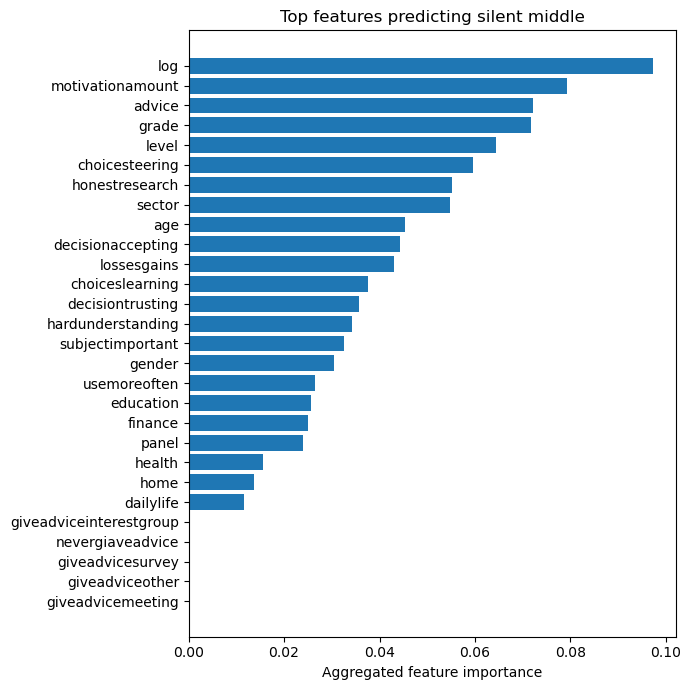

In [94]:
# Collapse one-hot features back to original variable names
fi_grouped = (
    fi.rename(lambda s: s.split("_")[0])  # crude but effective for most encodings
      .groupby(level=0)
      .sum()
      .sort_values(ascending=False)
)

TOP_N = 46
top_grouped = fi_grouped.head(TOP_N).sort_values()

plt.figure(figsize=(7, 7))
plt.barh(top_grouped.index, top_grouped.values)
plt.xlabel("Aggregated feature importance")
plt.title("Top features predicting silent middle")
plt.tight_layout()
plt.show()


In [95]:
"motivation_length" in X.columns

False